# SVM (Support Vector Machine) - recitation

``
In this short excersice, you will experience with implementing svm classifier for 2D points, in the linear case and with kernel method.
It may give you a basic understanding about the model and it's limits, and above all, about how it works.
``

In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.axes import Axes
from numpy.typing import NDArray

from svm_init import LOGGER, RANDOM_SEED

%matplotlib inline

DATA_DIRECTORY = Path.cwd().parent
OUTPUT_DIRECTORY = Path("outputs") / datetime.now().strftime(
    "svm_recitation_%Y%m%d_%H%M%S"
)
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=False)
plt.style.use("seaborn-v0_8-whitegrid")
LOGGER.info("Random seed: %d", RANDOM_SEED)
LOGGER.info("Output directory: %s", OUTPUT_DIRECTORY.resolve())

Random seed: 42


Output directory: C:\Users\asherk\PycharmProjects\DS_Training\D - ML\supervised\recitation\outputs\svm_recitation_20260802_142129


## Implementation of SVM

```If you remember, SVM (without regularization) is defined as follow:```

For dataset $X$ of $n$ vectors with dimension $k$ ($X$ has shape of $(n,k)$) and labels $Y$ (with values $\pm1$) :

We want to find a vector $w$ (of dimension $k$) and a number $b$, such that:

$$\sum_{j=1}^{k} w_j X_{ij} - b > 1 \Longrightarrow Y_i = 1$$
$$\sum_{j=1}^{k} w_j X_{ij} - b < -1 \Longrightarrow Y_i = -1$$

$w$ and $b$ are parameters of some plane (in 2D a plane is a line), that separate the space into 2 parts:
- one is where all the points x give $\sum_{j=1}^{k} w_j x_j - b \geq 0$
- one is where all the points x give $\sum_{j=1}^{k} w_j x_j - b < 0$

The rational is that by finding $w$ and $b$ that separate our points such that on one side the points with Y=+1, and on the other side the Y=-1, we could predict y for some new x, by taking $Y=sign(\sum_{j=1}^{k} w_j x_j - b)$

``The loss function that will punish us when `` $w$ `` and `` $b$ `` do not "follow the rules", is:``
$$Loss(w,b)=\frac{1}{n} \sum_{i=1}^{n} \max\{0, 1 - Y_i \cdot (\sum_{j=1}^{k} w_j X_{ij} - b)\}$$

``We see that if `` $(\sum_{j=1}^{k} w_j X_{ij} - b)$ `` and `` $Y_i$ `` has different signs the loss increase, and decrease otherwise.``

```Like the Linear and Logistic Regression, this problem can be solved by using Gradient Descent.
The derivatives of the loss are:```

$$\frac{dL(w,b)}{dw_j}=\frac{1}{n}\sum_{i=1}^{n}
\begin{cases}
    0 \hspace{1.5cm} , \hspace{0.5cm} \text{if} \hspace{0.4cm} Y_i \cdot (\sum_{j=1}^{k} w_j X_{ij} - b) > 1 \\ 
    - Y_i \cdot X_{ij} \hspace{0.1cm} , \hspace{0.5cm} \hspace{0.4cm} otherwise
\end{cases}$$

$$\frac{dL(w,b)}{db}=\frac{1}{n}\sum_{i=1}^{n}
\begin{cases}
    0 \hspace{1.7cm} , \hspace{0.5cm} \text{if} \hspace{0.4cm} Y_i \cdot (\sum_{j=1}^{k} w_j X_{ij} - b) > 1 \\ 
    Y_i \hspace{1.5cm} , \hspace{0.5cm} \hspace{0.4cm} otherwise
\end{cases}$$

```
And do gradient steps with it:
```

$$b_{l+1} = b_{l} - \alpha \frac{dL(w_l,b_l)}{db}, \hspace{1cm} w_{l+1} = w_{l} - \alpha \frac{dL(w_l,b_l)}{dw}$$

($\alpha$ = learning rate)

In [2]:
def predict(
    *,
    features: NDArray[np.floating],
    weights: NDArray[np.floating],
    bias: float,
) -> NDArray[np.floating]:
    """Calculate the signed distance numerator ``X @ w - b``.

    Args:
        features: Data matrix with shape ``(number_of_samples, number_of_features)``.
        weights: Separation vector with one value per feature.
        bias: Scalar subtracted from every linear score.

    Returns:
        One decision score per sample.
    """
    feature_matrix = np.asarray(a=features, dtype=np.float64)
    weight_vector = np.asarray(a=weights, dtype=np.float64)
    if feature_matrix.ndim != 2:
        raise ValueError("features must be a two-dimensional matrix.")
    if weight_vector.shape != (feature_matrix.shape[1],):
        raise ValueError("weights must contain exactly one value per feature.")
    return feature_matrix @ weight_vector - float(bias)


def linear_svm(
    *,
    features: NDArray[np.floating],
    labels: NDArray[np.floating],
    initial_weights: NDArray[np.floating] | None = None,
    initial_bias: float = 0.0,
    epochs: int = 1_000,
    learning_rate: float = 0.1,
    regularization_strength: float = 0.0,
) -> tuple[NDArray[np.floating], float, NDArray[np.floating]]:
    """Fit a linear SVM with full-batch subgradient descent.

    Args:
        features: Training matrix with samples in rows.
        labels: Binary labels encoded as zero and one.
        initial_weights: Optional starting weight vector; zeros are used by default.
        initial_bias: Starting value for the notebook's subtractive bias.
        epochs: Number of deterministic gradient updates.
        learning_rate: Positive step size.
        regularization_strength: Non-negative L2 penalty coefficient.

    Returns:
        Fitted weights, fitted bias, and the loss recorded before each update.
    """
    feature_matrix = np.asarray(a=features, dtype=np.float64)
    label_vector = np.asarray(a=labels, dtype=np.float64)
    if feature_matrix.ndim != 2:
        raise ValueError("features must be a two-dimensional matrix.")
    if label_vector.shape != (feature_matrix.shape[0],):
        raise ValueError("labels must contain exactly one value per sample.")
    if not np.all(a=np.isin(element=label_vector, test_elements=[0.0, 1.0])):
        raise ValueError("labels must contain only zero and one.")
    if epochs <= 0 or learning_rate <= 0.0:
        raise ValueError("epochs and learning_rate must be positive.")
    if regularization_strength < 0.0:
        raise ValueError("regularization_strength cannot be negative.")

    signed_labels = 2.0 * label_vector - 1.0
    number_of_samples, number_of_features = feature_matrix.shape
    if initial_weights is None:
        current_weights = np.zeros(shape=number_of_features, dtype=np.float64)
    else:
        current_weights = np.asarray(
            a=initial_weights, dtype=np.float64
        ).copy()
    if current_weights.shape != (number_of_features,):
        raise ValueError("initial_weights must contain one value per feature.")
    current_bias = float(initial_bias)
    loss_history = np.empty(shape=epochs, dtype=np.float64)

    for epoch_number in range(epochs):
        current_scores = predict(
            features=feature_matrix,
            weights=current_weights,
            bias=current_bias,
        )
        current_margins = signed_labels * current_scores
        active_margin_mask = current_margins <= 1.0
        hinge_losses = np.maximum(0.0, 1.0 - current_margins)
        loss_history[epoch_number] = float(np.mean(a=hinge_losses)) + (
            regularization_strength
            * float(np.dot(a=current_weights, b=current_weights))
            / 2.0
        )

        active_features = feature_matrix[active_margin_mask]
        active_labels = signed_labels[active_margin_mask]
        weight_gradient = (
            -(active_features.T @ active_labels) / number_of_samples
            + regularization_strength * current_weights
        )
        bias_gradient = float(np.sum(a=active_labels)) / number_of_samples
        current_weights = current_weights - learning_rate * weight_gradient
        current_bias = current_bias - learning_rate * bias_gradient

    return current_weights, current_bias, loss_history

The implementation records the loss before every update so convergence can be checked. Labels are converted from $\{0,1\}$ to $\{-1,+1\}$ exactly once, and only samples on or inside the unit margin contribute to the hinge-loss subgradient.

In [3]:
def plot_data(
    *,
    features: NDArray[np.floating],
    labels: NDArray[np.floating],
    x_label: str,
    y_label: str,
    positive_label: str,
    negative_label: str,
    x_minimum: float,
    x_maximum: float,
    y_minimum: float,
    y_maximum: float,
    axes: Axes | None = None,
) -> Axes:
    """Plot a two-dimensional binary dataset.

    Args:
        features: Two-dimensional feature matrix.
        labels: Binary labels encoded as zero and one.
        x_label: Horizontal-axis label.
        y_label: Vertical-axis label.
        positive_label: Legend text for class one.
        negative_label: Legend text for class zero.
        x_minimum: Lower horizontal-axis limit.
        x_maximum: Upper horizontal-axis limit.
        y_minimum: Lower vertical-axis limit.
        y_maximum: Upper vertical-axis limit.
        axes: Existing axes, or ``None`` to use the current axes.

    Returns:
        Axes containing the scatter plot.
    """
    feature_matrix = np.asarray(a=features, dtype=np.float64)
    label_vector = np.asarray(a=labels, dtype=np.float64)
    if feature_matrix.ndim != 2 or feature_matrix.shape[1] != 2:
        raise ValueError("features must have exactly two columns.")
    if label_vector.shape != (feature_matrix.shape[0],):
        raise ValueError("labels must contain exactly one value per sample.")

    plot_axes = plt.gca() if axes is None else axes
    positive_mask = label_vector == 1.0
    negative_mask = label_vector == 0.0
    plot_axes.scatter(
        feature_matrix[positive_mask, 0],
        feature_matrix[positive_mask, 1],
        marker="o",
        color="#003f5c",
        s=50,
        linewidths=1.5,
        label=positive_label,
    )
    plot_axes.scatter(
        feature_matrix[negative_mask, 0],
        feature_matrix[negative_mask, 1],
        marker="o",
        color="#ffa600",
        s=50,
        linewidths=1.5,
        label=negative_label,
    )
    plot_axes.set_xlim(left=x_minimum, right=x_maximum)
    plot_axes.set_ylim(bottom=y_minimum, top=y_maximum)
    plot_axes.set_xlabel(xlabel=x_label, fontsize=12)
    plot_axes.set_ylabel(ylabel=y_label, fontsize=12)
    plot_axes.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    return plot_axes

## Part 1 - Linear svm

```In this part we will see how to use SVM to find linear separation between data points.```

In [4]:
linear_data = pd.read_csv(
    filepath_or_buffer=DATA_DIRECTORY / "svm_dataset1.csv"
)
linear_features = linear_data[["x1", "x2"]].to_numpy(dtype=np.float64)
linear_labels = linear_data["label"].to_numpy(dtype=np.float64)
LOGGER.info(
    "Linear dataset: %d samples; class counts=%s",
    len(linear_data),
    linear_data["label"].value_counts().sort_index().to_dict(),
)

Linear dataset: 51 samples; class counts={0.0: 30, 1.0: 21}


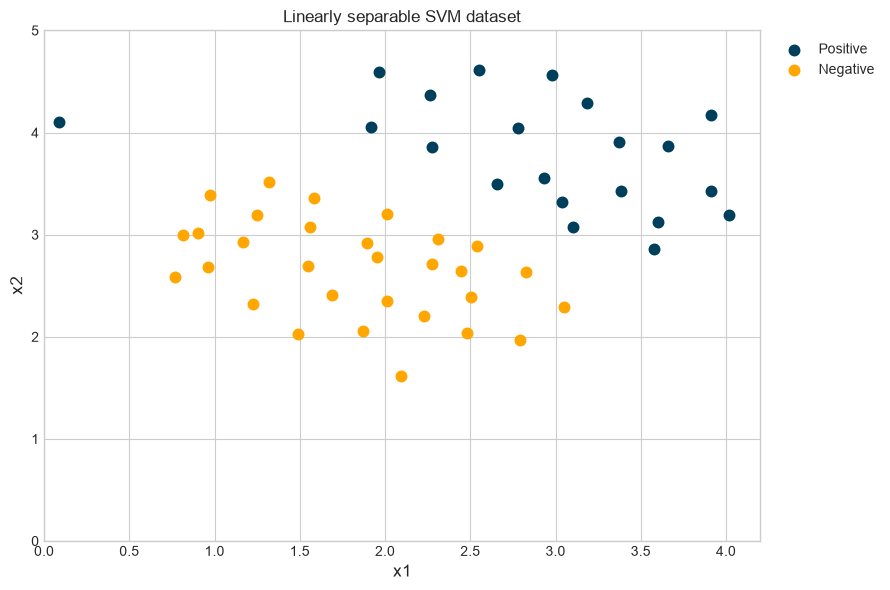

In [5]:
linear_data_figure, linear_data_axes = plt.subplots(figsize=(9, 6))
plot_data(
    features=linear_features,
    labels=linear_labels,
    x_label="x1",
    y_label="x2",
    positive_label="Positive",
    negative_label="Negative",
    x_minimum=0.0,
    x_maximum=4.2,
    y_minimum=0.0,
    y_maximum=5.0,
    axes=linear_data_axes,
)
linear_data_axes.set_title("Linearly separable SVM dataset")
linear_data_figure.tight_layout()
linear_data_path = OUTPUT_DIRECTORY / "linear_dataset.png"
linear_data_figure.savefig(fname=linear_data_path, dpi=160, bbox_inches="tight")
plt.show()

```First we will find the``` $w$ ```and``` $b$ ```of the separator:```

In [6]:
linear_weights, linear_bias, linear_loss_history = linear_svm(
    features=linear_features,
    labels=linear_labels,
    epochs=5_000,
    learning_rate=0.05,
)
linear_training_scores = predict(
    features=linear_features,
    weights=linear_weights,
    bias=linear_bias,
)
linear_training_predictions = (linear_training_scores >= 0.0).astype(np.float64)
linear_training_accuracy = float(
    np.mean(a=linear_training_predictions == linear_labels)
)
LOGGER.info("Linear SVM weights: %s", np.round(a=linear_weights, decimals=4))
LOGGER.info("Linear SVM bias: %.4f", linear_bias)
LOGGER.info("Linear SVM training accuracy: %.4f", linear_training_accuracy)
LOGGER.info(
    "Linear SVM hinge loss: %.6f -> %.6f",
    linear_loss_history[0],
    linear_loss_history[-1],
)

Linear SVM weights: [1.3142 1.9818]


Linear SVM bias: 9.5559


Linear SVM training accuracy: 0.9804


Linear SVM hinge loss: 1.000000 -> 0.097978


Plot the hyper plane:

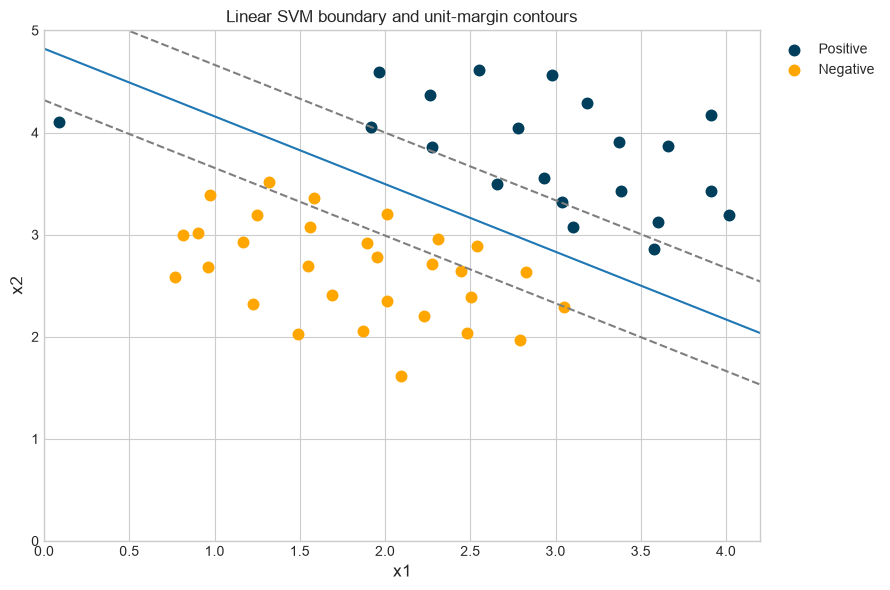

In [7]:
linear_grid_x1, linear_grid_x2 = np.meshgrid(
    np.arange(start=0.0, stop=5.0, step=0.01),
    np.arange(start=0.0, stop=5.0, step=0.01),
)
linear_grid_points = np.column_stack(
    (linear_grid_x1.ravel(), linear_grid_x2.ravel())
)
linear_grid_scores = predict(
    features=linear_grid_points,
    weights=linear_weights,
    bias=linear_bias,
).reshape(linear_grid_x1.shape)

linear_boundary_figure, linear_boundary_axes = plt.subplots(figsize=(9, 6))
plot_data(
    features=linear_features,
    labels=linear_labels,
    x_label="x1",
    y_label="x2",
    positive_label="Positive",
    negative_label="Negative",
    x_minimum=0.0,
    x_maximum=4.2,
    y_minimum=0.0,
    y_maximum=5.0,
    axes=linear_boundary_axes,
)
linear_boundary_axes.contour(
    linear_grid_x1,
    linear_grid_x2,
    linear_grid_scores,
    levels=[-1.0, 0.0, 1.0],
    colors=["tab:gray", "tab:blue", "tab:gray"],
    linestyles=["--", "-", "--"],
)
linear_boundary_axes.set_title("Linear SVM boundary and unit-margin contours")
linear_boundary_figure.tight_layout()
linear_boundary_path = OUTPUT_DIRECTORY / "linear_svm_boundary.png"
linear_boundary_figure.savefig(fname=linear_boundary_path, dpi=160, bbox_inches="tight")
plt.show()

## Part 2 - kernel SVM

```In this part we will see how to use SVM to find non-linear separation between data points.```

In [8]:
nonlinear_data = pd.read_csv(
    filepath_or_buffer=DATA_DIRECTORY / "svm_dataset2.csv"
)
nonlinear_features = nonlinear_data[["x1", "x2"]].to_numpy(dtype=np.float64)
nonlinear_labels = nonlinear_data["label"].to_numpy(dtype=np.float64)
LOGGER.info(
    "Nonlinear dataset: %d samples; class counts=%s",
    len(nonlinear_data),
    nonlinear_data["label"].value_counts().sort_index().to_dict(),
)

Nonlinear dataset: 863 samples; class counts={0.0: 383, 1.0: 480}


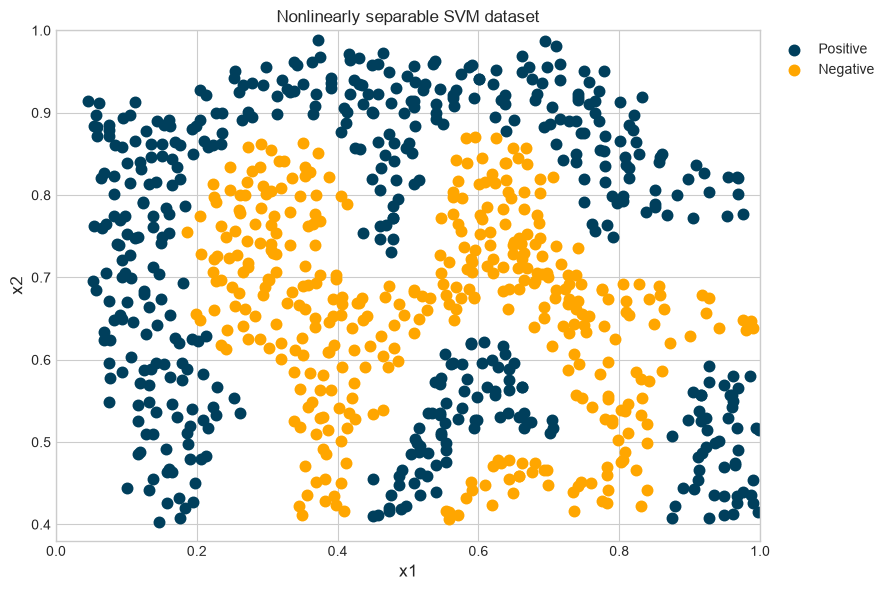

In [9]:
nonlinear_data_figure, nonlinear_data_axes = plt.subplots(figsize=(9, 6))
plot_data(
    features=nonlinear_features,
    labels=nonlinear_labels,
    x_label="x1",
    y_label="x2",
    positive_label="Positive",
    negative_label="Negative",
    x_minimum=0.0,
    x_maximum=1.0,
    y_minimum=0.38,
    y_maximum=1.0,
    axes=nonlinear_data_axes,
)
nonlinear_data_axes.set_title("Nonlinearly separable SVM dataset")
nonlinear_data_figure.tight_layout()
nonlinear_data_path = OUTPUT_DIRECTORY / "nonlinear_dataset.png"
nonlinear_data_figure.savefig(fname=nonlinear_data_path, dpi=160, bbox_inches="tight")
plt.show()

``How can we seperate thses points with a straight line?``

``The solution is that for every point x, we are going to add a lot of features. With those features the point are now have more dimensions then 2, and we can search linear separation in the high dimention.``

The way we do it with Kernel method, is by choosing dataset $X_2$ of $n$ points, and add features to our dataset X by:
- ``Choosing a distance measure distance(x1, x2). In our case the "gaussian kernel" or "rbf").``
- ``For every point x in X, we compute the distance for every point x_2 in X_2.``

Now for every point $x$ in $X$ we have $n$ features instead of 2. ($x_{new} = \{dist(x, X_2[1]),...,dist(x, X_2[n])\}$)

``The gaussian kernel is defined as:``
$$K_{distance}(x1, x2)=exp(\frac{\sum (x1_j \cdot x2_j)^2}{2 \cdot \sigma^2})$$
Where $\sigma$ is a parameter chosen by us (for now it will be 0.1).

($exp(a)=e^{a}$)

> **Formula correction.** The standard Gaussian/RBF similarity is
>
> $$K(x,z)=\exp\left(-\frac{\lVert x-z\rVert_2^2}{2\sigma^2}\right).$$
>
> The minus sign and squared Euclidean distance are essential: identical points have similarity 1, and similarity decreases toward 0 as points move apart. The equation printed above omits these properties, so the implementation below uses the standard definition.

```Usually ``` $X_2$ ``` is the training data. The rational is that we want to "linearly separate" points that close to training points with Y=+1, from points that close to training points with Y=-1```

In [10]:
def gaussian_kernel_function(
    *,
    features: NDArray[np.floating],
    landmark_features: NDArray[np.floating],
    sigma: float = 0.1,
) -> NDArray[np.floating]:
    """Transform samples into Gaussian-RBF similarities to landmarks.

    Args:
        features: Sample matrix with shape ``(number_of_samples, dimensions)``.
        landmark_features: Landmark matrix with the same feature dimension.
        sigma: Positive Gaussian bandwidth.

    Returns:
        RBF similarity matrix with one column per landmark.
    """
    feature_matrix = np.asarray(a=features, dtype=np.float64)
    landmark_matrix = np.asarray(a=landmark_features, dtype=np.float64)
    if feature_matrix.ndim != 2 or landmark_matrix.ndim != 2:
        raise ValueError("features and landmark_features must be two-dimensional.")
    if feature_matrix.shape[1] != landmark_matrix.shape[1]:
        raise ValueError("Feature and landmark dimensions must match.")
    if sigma <= 0.0:
        raise ValueError("sigma must be positive.")

    feature_squared_norms = np.sum(
        a=feature_matrix * feature_matrix, axis=1, keepdims=True
    )
    landmark_squared_norms = np.sum(
        a=landmark_matrix * landmark_matrix, axis=1, keepdims=True
    ).T
    squared_distances = np.maximum(
        0.0,
        feature_squared_norms
        + landmark_squared_norms
        - 2.0 * (feature_matrix @ landmark_matrix.T),
    )
    return np.exp(-squared_distances / (2.0 * sigma**2))

We want to train on our $X$, and the features dataset for the kernel will also be $X$:

In [11]:
kernel_sigma = 0.1
nonlinear_training_kernel = gaussian_kernel_function(
    features=nonlinear_features,
    landmark_features=nonlinear_features,
    sigma=kernel_sigma,
)
kernel_weights, kernel_bias, kernel_loss_history = linear_svm(
    features=nonlinear_training_kernel,
    labels=nonlinear_labels,
    epochs=1_000,
    learning_rate=0.1,
)
kernel_training_scores = predict(
    features=nonlinear_training_kernel,
    weights=kernel_weights,
    bias=kernel_bias,
)
kernel_training_accuracy = float(
    np.mean(a=(kernel_training_scores >= 0.0) == nonlinear_labels)
)
LOGGER.info("Kernel SVM training accuracy: %.4f", kernel_training_accuracy)
LOGGER.info(
    "Kernel SVM hinge loss: %.6f -> %.6f",
    kernel_loss_history[0],
    kernel_loss_history[-1],
)

Kernel SVM training accuracy: 0.9838


Kernel SVM hinge loss: 1.000000 -> 0.064276


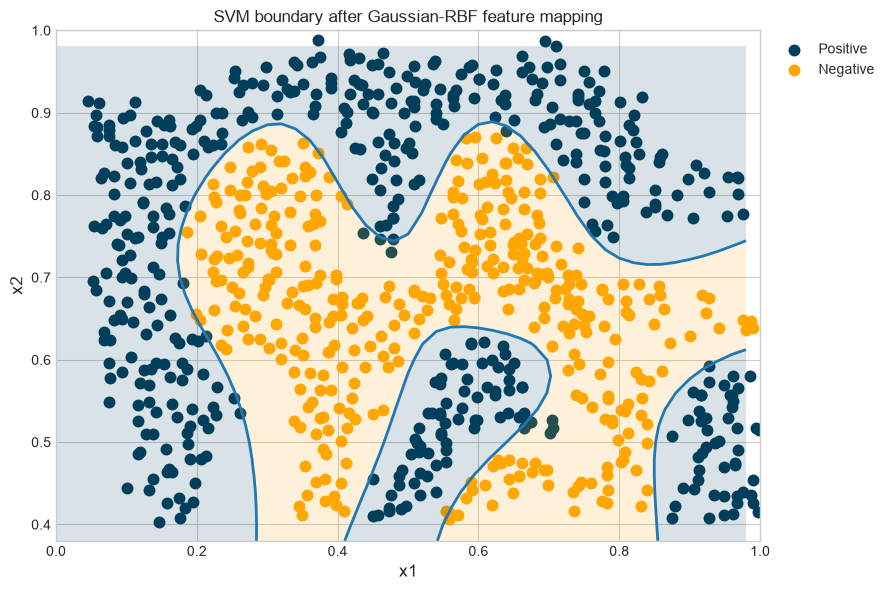

In [12]:
kernel_grid_x1, kernel_grid_x2 = np.meshgrid(
    np.arange(start=0.0, stop=1.0, step=0.02),
    np.arange(start=0.38, stop=1.0, step=0.02),
)
kernel_grid_points = np.column_stack(
    (kernel_grid_x1.ravel(), kernel_grid_x2.ravel())
)
kernel_grid_features = gaussian_kernel_function(
    features=kernel_grid_points,
    landmark_features=nonlinear_features,
    sigma=kernel_sigma,
)
kernel_grid_scores = predict(
    features=kernel_grid_features,
    weights=kernel_weights,
    bias=kernel_bias,
).reshape(kernel_grid_x1.shape)

kernel_boundary_figure, kernel_boundary_axes = plt.subplots(figsize=(9, 6))
plot_data(
    features=nonlinear_features,
    labels=nonlinear_labels,
    x_label="x1",
    y_label="x2",
    positive_label="Positive",
    negative_label="Negative",
    x_minimum=0.0,
    x_maximum=1.0,
    y_minimum=0.38,
    y_maximum=1.0,
    axes=kernel_boundary_axes,
)
kernel_boundary_axes.contourf(
    kernel_grid_x1,
    kernel_grid_x2,
    kernel_grid_scores,
    levels=[-np.inf, 0.0, np.inf],
    colors=["#ffa600", "#003f5c"],
    alpha=0.15,
)
kernel_boundary_axes.contour(
    kernel_grid_x1,
    kernel_grid_x2,
    kernel_grid_scores,
    levels=[0.0],
    colors=["tab:blue"],
    linewidths=2.0,
)
kernel_boundary_axes.set_title("SVM boundary after Gaussian-RBF feature mapping")
kernel_boundary_figure.tight_layout()
kernel_boundary_path = OUTPUT_DIRECTORY / "kernel_svm_boundary.png"
kernel_boundary_figure.savefig(fname=kernel_boundary_path, dpi=160, bbox_inches="tight")
plt.show()

The boundary is nonlinear in the original two coordinates, but it is linear in the 863-dimensional similarity representation. Each transformed coordinate measures how similar a point is to one training landmark.

# Bonus - regularized SVM

```Change "linear_svm" to support regularization according to the regularized Loss function:```

$$Loss(w,b)= \sum_{i=1}^{n} \max\{0, 1 - Y_i \cdot (\sum_{j=1}^{k} w_j X_{ij} - b)\} + \frac{\lambda}{2}\sum_{j=1}^{k} w_j^2$$

```Where ``` $\lambda$ ``` is the regularization parameter```

> **Scaling convention.** The implementation uses mean hinge loss plus $\frac{\lambda}{2}\lVert w\rVert_2^2$. Averaging the hinge term makes the learning rate independent of dataset size; it only rescales the numerical interpretation of $\lambda$ relative to the displayed summed-loss equation.

In [13]:
def regularized_linear_svm(
    *,
    features: NDArray[np.floating],
    labels: NDArray[np.floating],
    regularization_strength: float = 1.0,
    initial_weights: NDArray[np.floating] | None = None,
    initial_bias: float = 0.0,
    epochs: int = 1_000,
    learning_rate: float = 0.1,
) -> tuple[NDArray[np.floating], float, NDArray[np.floating]]:
    """Fit the notebook SVM with an L2 penalty on its weights.

    Args:
        features: Training matrix with samples in rows.
        labels: Binary labels encoded as zero and one.
        regularization_strength: Non-negative L2 coefficient, conventionally lambda.
        initial_weights: Optional starting weight vector.
        initial_bias: Initial subtractive bias.
        epochs: Number of full-batch updates.
        learning_rate: Positive subgradient step size.

    Returns:
        Fitted weights, fitted bias, and regularized loss history.
    """
    return linear_svm(
        features=features,
        labels=labels,
        initial_weights=initial_weights,
        initial_bias=initial_bias,
        epochs=epochs,
        learning_rate=learning_rate,
        regularization_strength=regularization_strength,
    )

In [14]:
# Reuse the already loaded linear dataset from Part 1.

```Plot the comparison between the regularized w and the regular one:```

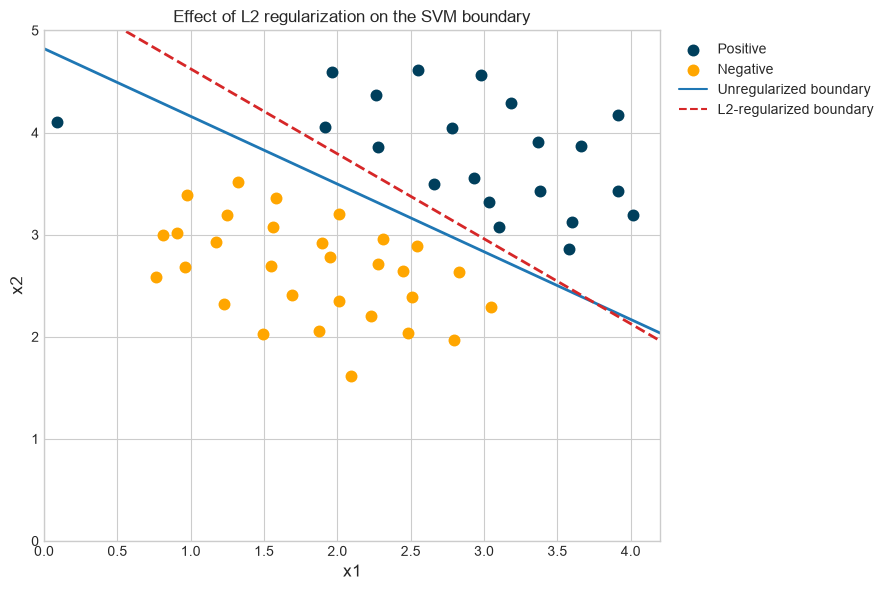

Weight norms — unregularized: 2.3779; regularized: 1.0350


Regularized linear SVM training accuracy: 0.9804


Timestamped output files: C:\Users\asherk\PycharmProjects\DS_Training\D - ML\supervised\recitation\outputs\svm_recitation_20260802_142129


In [15]:
regularized_weights, regularized_bias, regularized_loss_history = (
    regularized_linear_svm(
        features=linear_features,
        labels=linear_labels,
        regularization_strength=0.3,
        epochs=5_000,
        learning_rate=0.05,
    )
)
unregularized_weights, unregularized_bias, _ = linear_svm(
    features=linear_features,
    labels=linear_labels,
    epochs=5_000,
    learning_rate=0.05,
)

regularized_grid_scores = predict(
    features=linear_grid_points,
    weights=regularized_weights,
    bias=regularized_bias,
).reshape(linear_grid_x1.shape)
unregularized_grid_scores = predict(
    features=linear_grid_points,
    weights=unregularized_weights,
    bias=unregularized_bias,
).reshape(linear_grid_x1.shape)

comparison_figure, comparison_axes = plt.subplots(figsize=(9, 6))
plot_data(
    features=linear_features,
    labels=linear_labels,
    x_label="x1",
    y_label="x2",
    positive_label="Positive",
    negative_label="Negative",
    x_minimum=0.0,
    x_maximum=4.2,
    y_minimum=0.0,
    y_maximum=5.0,
    axes=comparison_axes,
)
comparison_axes.contour(
    linear_grid_x1,
    linear_grid_x2,
    unregularized_grid_scores,
    levels=[0.0],
    colors=["tab:blue"],
    linewidths=2.0,
)
comparison_axes.contour(
    linear_grid_x1,
    linear_grid_x2,
    regularized_grid_scores,
    levels=[0.0],
    colors=["tab:red"],
    linestyles=["--"],
    linewidths=2.0,
)
comparison_axes.plot([], [], color="tab:blue", label="Unregularized boundary")
comparison_axes.plot(
    [], [], color="tab:red", linestyle="--", label="L2-regularized boundary"
)
comparison_axes.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
comparison_axes.set_title("Effect of L2 regularization on the SVM boundary")
comparison_figure.tight_layout()
regularization_path = OUTPUT_DIRECTORY / "regularization_comparison.png"
comparison_figure.savefig(fname=regularization_path, dpi=160, bbox_inches="tight")
plt.show()

regularized_predictions = (
    predict(
        features=linear_features,
        weights=regularized_weights,
        bias=regularized_bias,
    )
    >= 0.0
).astype(np.float64)
LOGGER.info(
    "Weight norms — unregularized: %.4f; regularized: %.4f",
    float(np.linalg.norm(x=unregularized_weights)),
    float(np.linalg.norm(x=regularized_weights)),
)
LOGGER.info(
    "Regularized linear SVM training accuracy: %.4f",
    float(np.mean(a=regularized_predictions == linear_labels)),
)
LOGGER.info("Timestamped output files: %s", OUTPUT_DIRECTORY.resolve())

L2 regularization pulls the weight vector toward zero. This usually widens the geometric margin and makes the separator less sensitive to individual samples, at the cost of allowing more margin violations when the penalty is strong. The logged norms quantify that shrinkage for this dataset.